# ASSIGNMENT 3
# Submission Deadline: 07/03/2026, 11:59 PM
# Submission Link: [https://forms.gle/GhWPFtoojPWm2xWs8](https://forms.gle/GhWPFtoojPWm2xWs8)

# Provide Information
<a id="Provide-Information"></a>

Name: **YOUR FULL NAME GOES HERE**

Roll No.: **YOUR ROLL NO**

IITK EMail: **email@iitk.ac.in**

# Instructions
<a id="Instructions"></a>


**Read all the instructions below carefully before you start working on the assignment.**
- The purpose of this course is that you learn RL and the best way to do that is by implementation and experimentation.
- The assignment requires your to implement some algorithms and you are required report your findings after experimenting with those algorithms.
- **You are required to submit this Jupyter notebook (.ipynb). The notebook would include the code, graphs/plots of the experiments you run and your findings/observations.**
- In case you use any maths in your explanations, render it using latex in the Jupyter notebook.
- You are expected to implement algorithms on your own and not copy it from other sources/class mates. Of course, you can refer to lecture slides.
- If you use any reference or material (including code), please cite the source, else it will be considered plagiarism. But referring to other sources that directly solve the problems given in the assignment is not allowed. There is a limit to which you can refer to outside material.
- This is an individual assignment.
- In case your solution is found to have an overlap with solution by someone else (including external sources), all the parties involved will get zero in this and all future assignments plus further more penalties in the overall grade. We will check not just for lexical but also semantic overlap. Same applies for the code as well. Even an iota of cheating would NOT be tolerated. If you cheat one line or cheat one page the penalty would be same.
- Be a smart agent, think long term, if you cheat we will discover it somehow, the price you would be paying is not worth it.
- In case you are struggling with the assignment, seek help from TAs. Cheating is not an option! I respect honesty and would be lenient if you are not able to solve some questions due to difficulty in understanding. Remember we are there to help you out, seek help if something is difficult to understand.
- The deadline for the submission is given above. Submit at least 30 minutes before the deadline, lot can happen at the last moment, your internet can fail, there can be a power failure, you can be abducted by aliens, etc.
- You have to submit your assignment via the Google Form (link above)
- The form would close after the deadline and we will not accept any solution. No reason what-so-ever would be accepted for not being able to submit before the deadline.
- Since the assignment involves experimentation, reporting your results and observations, there is a lot of scope for creativity and innovation and presenting new perspectives. Such efforts would be highly appreciated and accordingly well rewarded. Be an exploratory agent!
- Your code should be very well documented, there are marks for that.
- In your plots, have a clear legend and clear lines, etc. Of course you would generating the plots in your code but you must also put these plots in your notebook.
- For all experiments, report about the seed used in the code documentation, write about the seed used.
- In your notebook write about all things that are not obvious from the code e.g., if you have made any assumptions, references/sources, running time, etc.
-  **DO NOT Forget to write name, roll no and email details above**
- **In addition to checking your code, we will be conducting one-on-one viva for the evaluation. So please make sure that you do not cheat!**
- For each of the sub-part in the question create a new cell below the question and put your answer in there. This includes the plots as well

## OpenAI Gym Environments


### Random-Maze Environment

In this assignment we will be exploring a variant of the **Random Maze Environment (RME)** that we have been looking at in the lectures.

#### Environment Description

The environment is represented as a **grid world** (Figure a). Random maze environment is a **highly stochastic environment** with:

- **11 states**: Two terminal states (a goal state **G** and a hole state **H**) and 9 non-terminal states
- **A wall** in between the environment

The **wall behaves similar to the wall on the periphery** of the environment: if an agent bumps against the wall, it **bounces back**. The boundary of the environment behaves similarly.

#### Grid Layout (3×4):

```
[ 0 ][ 1 ][ 2 ][ 3-G ]
[ 4 ][  5-WALL  ][ 6 ][ 7-H ]
[ 8-S ][ 9 ][ 10][ 11]
```

Where:
- **S** (State 8): Start state
- **G** (State 3): Goal state
- **H** (State 7): Hole state
- **WALL** (State 5): Wall state (agent bounces back)

#### Rewards:

- Agent receives a reward of **+1** when it lands in the **goal state (3)**
- Agent receives a reward of **-1** when it lands in the **hole state (7)**
- For rest of the transitions, there is a reward of **-0.04** (living cost)

#### Transitions:

The transitions are **stochastic** as shown in Figure b. In this environment, **four actions** are possible: **left (2)**, **up (1)**, **right (0)**, and **down (3)**.

For every intended action:
- There is **80% chance** of going in the intended direction
- Remaining **20% chance** of going in either of the orthogonal directions
- The 20% chance gets **equally distributed** between each of the orthogonal directions (10% each)

The agent starts from **state 8 (S)**.

#### Discount Factor:

Assume **γ = 0.99** for all problems below.

---

**NOTE:** State 5 is a **WALL**. When implementing the environment, make sure the agent **bounces back** to its current state when it tries to move to state 5!


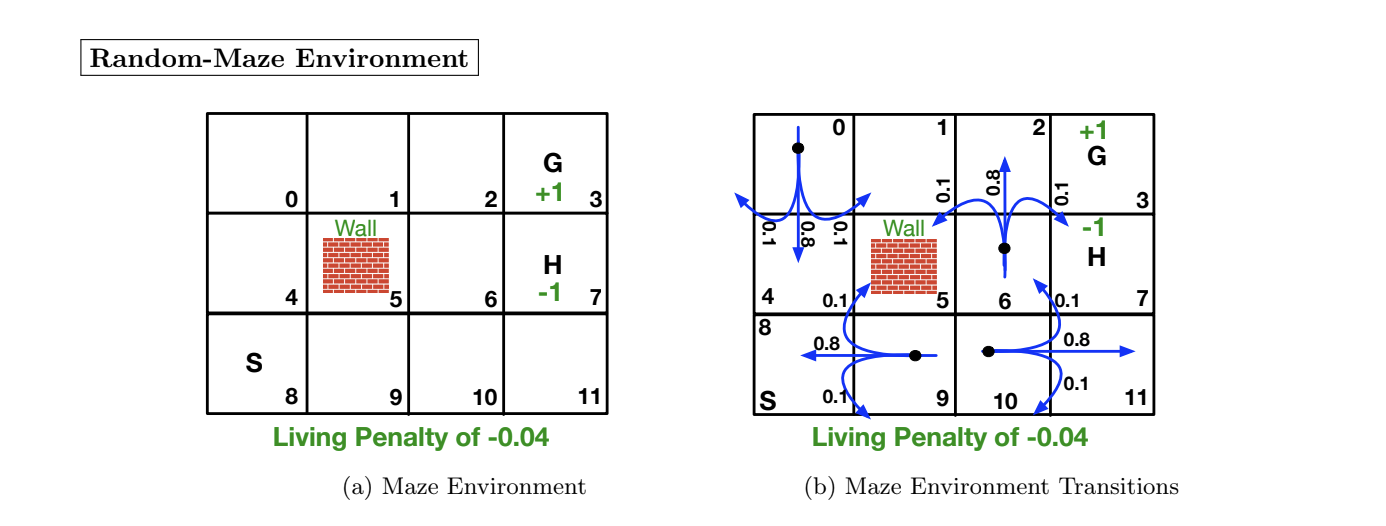

In [ ]:
# All imports go in here
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from gymnasium import Env, spaces
from gymnasium.envs.registration import register
import random
import os
import math
from tqdm import trange


---

# Problem 1: Random-Maze Environment Implementation (30 Marks)

## Introduction

In this problem, you need to create a custom environment using **Gymnasium (formerly OpenAI Gym)** for the Random Maze described above.

### Requirements:

1. **Implement the SlipperyMazeEnv class** that inherits from `gym.Env`
2. **Correctly handle the wall at state 5** - agent must bounce back when trying to move there
3. **Implement stochastic transitions** - 80% intended direction, 10% each orthogonal
4. **Handle boundary conditions** properly
5. **Implement reward structure** as specified
6. **Create comprehensive test cases** to verify your environment works correctly



---


In [1]:
class SlipperyMazeEnv(gym.Env):
    """
    A stochastic grid-based maze environment where actions may result
    in unintended movements due to slippery transitions.

    CRITICAL: State 5 is a WALL - agent bounces back if it tries to move there!
    """

    def __init__(self, config=None):
        """
        Initialize the Slippery Maze Environment.

        Args:
            config: Dictionary containing environment configuration
        """
        super().__init__()
        self.observation_space = spaces.Discrete(config['environment']['total_states'])
        self.action_space = spaces.Discrete(config['environment']['total_actions'])
        self.goal_state = config['environment']['goal_state']
        self.hole_state = config['environment']['hole_state']
        self.wall_state = config['environment']['wall_state']
        self.living_reward = config['environment']['living_reward']
        self.goal_reward = config['environment']['goal_reward']
        self.hole_reward = config['environment']['hole_reward']
        self.agent_location = config['environment']['start_state']
        self.terminal_states = [self.goal_state, self.hole_state]

        pass

    def make_environment(self, config):
        """
        Creates the transition probability model P[s][a] for the maze.

        Grid Layout (3x4):
        [ 0][ 1][ 2][ 3-G]
        [ 4][  5-WALL  ][ 6][ 7-H]
        [ 8-S][ 9][10][11]

        Actions: 0=right, 1=up, 2=left, 3=down

        Returns:
            P: Dictionary where P[state][action] = [(prob, next_state, reward, done), ...]
        """
        P = {}
        rows, cols = 3, 4
        goal_state = 3
        hole_state = 7
        wall_state = 5

        # Action vectors: 0=right, 1=up, 2=left, 3=down
        action_deltas = {
            0: (0, 1),   # Right
            1: (-1, 0),  # Up
            2: (0, -1),  # Left
            3: (1, 0)    # Down
        }

        for s in range(rows * cols):
            P[s] = {a: [] for a in range(4)}

            # If it's a terminal state, the episode is over.
            # Standard convention: loop in terminal state with 0 reward.
            if s in [goal_state, hole_state]:
                for a in range(4):
                    P[s][a] = [(1.0, s, 0.0, True)]
                continue

            # If the state is the wall itself (shouldn't be reachable, but just in case)
            if s == wall_state:
                for a in range(4):
                    P[s][a] = [(1.0, s, 0.0, False)]
                continue

            # For non-terminal states, compute transitions for each action
            for a in range(4):
                # Probabilities: 80% intended, 10% for each orthogonal direction
                transitions = {
                    a: 0.8,
                    (a - 1) % 4: 0.1,  # Orthogonal 1
                    (a + 1) % 4: 0.1   # Orthogonal 2
                }

                # Dictionary to accumulate probabilities for identical next states
                # (e.g., if moving Up and Left both hit a boundary)
                next_state_probs = {}

                for m, prob in transitions.items():
                    r, c = s // cols, s % cols
                    dr, dc = action_deltas[m]
                    nr, nc = r + dr, c + dc

                    # Check grid boundaries
                    if 0 <= nr < rows and 0 <= nc < cols:
                        next_s = nr * cols + nc
                        # Check wall collision
                        if next_s == wall_state:
                            next_s = s  # Bounce back
                    else:
                        next_s = s  # Bounce back from boundary

                    # Accumulate probability
                    next_state_probs[next_s] = next_state_probs.get(next_s, 0.0) + prob

                # Construct the final tuple list for P[s][a]
                for next_s, prob in next_state_probs.items():
                    if next_s == goal_state:
                        reward = 1.0
                        done = True
                    elif next_s == hole_state:
                        reward = -1.0
                        done = True
                    else:
                        reward = -0.04  # Living cost
                        done = False

                    P[s][a].append((prob, next_s, reward, done))

        return P

    def is_terminated(self, state):
        """
        Check if the given state is a terminal state.

        Args:
            state: Current state

        Returns:
            bool: True if state is goal or hole, False otherwise
        """
        # TODO: Implement
        if state in self.terminal_states:
            return True
        else:
            return False

    def get_reward(self, state):
        """
        Get the reward for transitioning to the given state.

        Args:
            state: State to get reward for

        Returns:
            float: +1 for goal, -1 for hole, -0.04 for others
        """
        # TODO: Implement
        if state == self.goal_state:
            return self.goal_reward
        elif state == self.hole_state:
            return self.hole_reward
        else:
            return self.living_reward

    def get_obs(self):
        """Get current observation."""
        return {'agent': self.agent_location, 'terminals': self.terminal_states}

    def get_info(self):
        """Get additional information."""
        state_x = self.agent_location // self.config['maze_shape'][1]
        state_y = self.agent_location % self.config['maze_shape'][1]
        goal_x = self.GOAL_STATE // self.config['maze_shape'][1]
        goal_y = self.GOAL_STATE % self.config['maze_shape'][1]
        return {'distance': abs(state_x - goal_x) + abs(state_y - goal_y)}

    def reset(self, seed=None, options=None):
        """
        Reset the environment to the initial state.

        Args:
            seed: Random seed for reproducibility
            options: Additional options

        Returns:
            observation: Initial observation
            info: Additional information
        """
        super().reset(seed=seed)
        self.agent_location = self.config['environment']['start_state']
        return self.get_obs(), self.get_info()


        pass

    def step(self, action):
        """
        Execute one time step within the environment.

        Args:
            action: Action to take (0=right, 1=up, 2=left, 3=down)

        Returns:
            observation: New observation after taking action
            reward: Reward received
            terminated: Whether episode has terminated
            truncated: Whether episode was truncated
            info: Additional information
        """
        state = self.agent_location
        transitions = self.P[state][action]

        # Sample from the transitions based on their probabilities
        probs, next_states, rewards, dones = zip(*transitions)
        next_state = np.random.choice(next_states, p=probs)
        reward = rewards[next_states.index(next_state)]
        terminated = dones[next_states.index(next_state)]
        self.agent_location = next_state
        return self.get_obs(), reward, terminated, False, self.get_info()

    def render(self):
        """Render the environment (optional)."""
        pass

    def close(self):
        """Close the environment (optional)."""
        pass


NameError: name 'Env' is not defined

In [2]:
# Register the environment with Gymnasium
register(
    id='SlipperyMazeEnvironment-v0',
    entry_point='__main__:SlipperyMazeEnv',
    max_episode_steps=1000,
    reward_threshold=1.0,
)


NameError: name 'register' is not defined

In [ ]:
# Configuration for the environment and algorithms
CONFIG = {
    'seed': 46873,
    'environment': {
        'total_states': 3*4,
        'maze_shape': (3, 4),
        'living_reward': -0.04,
        'total_actions': 4,
        'start_state': 8,
        'goal_state': 3,
        'hole_state': 7,
        'goal_reward': 1,
        'hole_reward': -1,
        'wall_state': 5,  # State 5 is the WALL!
    },
    'gamma': 0.99,  # Discount factor
    'theta': 0.01,  # Convergence threshold for DP algorithms
}


## Test Cases

Implement comprehensive test cases to verify your environment implementation. Below are suggested tests:

### Testing Requirements:

You must implement and describe the following test cases:

- **Test 1:** Verify wall at state 5 works correctly (agent bounces back)
- **Test 2:** Verify stochastic transitions (check probabilities)
- **Test 3:** Verify rewards are assigned correctly
- **Test 4:** Verify terminal states work properly
- **Test 5:** Verify boundary conditions (agent doesn't go outside grid)


----

In [ ]:
# TODO: Implement Test Cases

# Test 1: Wall Behavior at State 5
# Description: Verify that when agent tries to move to state 5, it bounces back



# Test 2: Stochastic Transitions
# Description: Verify transition probabilities are correct (80%, 10%, 10%, 0%)



# Test 3: Reward Structure
# Description: Verify rewards are assigned correctly



# Test 4: Terminal States
# Description: Verify goal and hole are terminal



# Test 5: Boundary Conditions
# Description: Verify agent doesn't go outside grid


pass


---

# Problem 2: RME Optimal Policy via Dynamic Programming (90 Marks)

## Introduction

In this problem, we **assume we know the underlying MDP** of the Random Maze Environment. We are interested in finding the **optimal policy** for this environment using **Dynamic Programming** methods.

Dynamic Programming methods are guaranteed to find the optimal policy when the MDP is known. We will implement and compare two classic DP algorithms:

1. **Policy Iteration (PI)**
2. **Value Iteration (VI)**

### Key Concepts:

- **Policy Evaluation:** Compute value function $V^π$ for a given policy $π$
- **Policy Improvement:** Generate better policy from value function
- **Value Iteration:** Combine evaluation and improvement in one step
- **Convergence:** Use threshold $θ = 10^{(-10)}$ to determine when to stop

---


## Part 1: Policy Iteration (40 Marks)

### Algorithm Overview:

Policy Iteration alternates between two steps:

1. **Policy Evaluation:** Given a policy $π$, compute $V^π(s)$  for all states
   - Iteratively solve: $V(s) \leftarrow \sum_a \pi(a|s) \sum_{s',~r} p(s',r|s,a)[r + \gamma V(s')]$

   - Stop when $max|V_{new}(s) - V_{old}(s)| < θ$

2. **Policy Improvement:** Update policy greedily w.r.t. current $V$

   - $π(s) ← argmax_{a}~Σ_{s',~r} p(s',r|s,a)[r + γV(s')]$
   
   - If policy doesn't change, we have found optimal policy

### Requirements:

1. **Implement `policy_evaluation(env, policy, gamma, theta, config)`**
   - Input: Environment, current policy, discount factor, threshold
   - Output: Value function $V$ for given policy
   - Must converge when $max~change < θ$

2. **Implement `policy_improvement(env, V, gamma, config)`**
   - Input: Environment, value function, discount factor
   - Output: Improved policy, boolean indicating if policy changed
   - Must select greedy action for each state

3. **Implement `policy_iteration(env, gamma, theta, config)`**
   - Input: Environment, discount factor, threshold
   - Output: Optimal policy, optimal value function, number of iterations
   - Must alternate between evaluation and improvement until convergence

### Deliverables:

1. **Code Implementation:** Complete working implementation of all three functions
2. **Initial Policy Description:** Clearly describe the random policy you started with
3. **Optimal Policy Visualization:** Draw/plot the final optimal policy obtained
4. **Convergence Analysis:** Report how many iterations required to converge
5. **Discussion:** Explain any interesting observations


In [ ]:
def policy_evaluation(env, policy, gamma, theta, config):
    """
    Evaluate a policy given an environment and a discount factor.

    This function computes the value function V^π(s) for all states under
    the given policy π using iterative policy evaluation.

    Args:
        env: The environment (with transition model env.P)
        policy: Current policy (numpy array of shape [num_states, num_actions])
                policy[s, a] = probability of taking action a in state s
        gamma: Discount factor (0.99)
        theta: Convergence threshold (1e-10)
        config: Configuration dictionary

    Returns:
        V: Value function (numpy array of shape [num_states])
           V[s] = expected return starting from state s following policy π
    """
    # TODO: Implement policy evaluation
    pass


def policy_improvement(env, V, gamma, config):
    """
    Improve policy greedily with respect to the current value function.

    This function generates a better (or equally good) policy by acting
    greedily with respect to the current value function V.

    Args:
        env: The environment (with transition model env.P)
        V: Current value function (numpy array of shape [num_states])
        gamma: Discount factor (0.99)
        config: Configuration dictionary

    Returns:
        policy: Improved policy (numpy array of shape [num_states, num_actions])
                policy[s, a] = 1 if a = argmax Q(s,a), else 0
        policy_stable: Boolean indicating if policy changed
                      True = policy didn't change (converged)
                      False = policy changed (need another iteration)
    """
    # TODO: Implement policy improvement
    pass


def policy_iteration(env, gamma, theta, config):
    """
    Find optimal policy using Policy Iteration algorithm.

    This function alternates between policy evaluation and policy improvement
    until the policy converges to the optimal policy π*.

    Args:
        env: The environment (with transition model env.P)
        gamma: Discount factor (0.99)
        theta: Convergence threshold for policy evaluation (1e-10)
        config: Configuration dictionary

    Returns:
        policy: Optimal policy (numpy array)
        V: Optimal value function (numpy array)
        iterations: Number of iterations until convergence

    """
    # TODO: Implement policy iteration
    pass


## Part 2: Value Iteration (40 Marks)

### Algorithm Overview:

Value Iteration combines policy evaluation and improvement into a single update:

- **Single Update:** $V(s) ← max_a ~Σ_{s',~r} p(s',r|s,a)~[r + γV(s')]$

- **Convergence:** Stop when $max~|V_{new}(s) - V_{old}(s)| < θ$

- **Extract Policy:** After convergence, extract greedy policy

### Key Difference from Policy Iteration:

- **PI:** Fully evaluate each policy before improving it
- **VI:** Update value function with max over actions directly (no explicit policy)

### Requirements:

1. **Implement `value_iteration(env, gamma, theta, config)`**
   - Input: Environment, discount factor, threshold
   - Output: Optimal value function, optimal policy, number of iterations
   - Must use Bellman optimality equation for updates

### Deliverables:

1. **Code Implementation:** Complete working implementation of value iteration
2. **Initial Values Description:** Describe how you initialized V (typically all zeros)
3. **Optimal Policy Visualization:** Draw/plot the final optimal policy obtained
4. **Convergence Analysis:** Report how many iterations required to converge
5. **Discussion:** Compare convergence with Policy Iteration


In [ ]:
def value_iteration(env, gamma, theta, config):
    """
    Find optimal policy using Value Iteration algorithm.

    This function iteratively updates the value function using the Bellman
    optimality equation until convergence, then extracts the optimal policy.

    Args:
        env: The environment (with transition model env.P)
        gamma: Discount factor (0.99)
        theta: Convergence threshold (1e-10)
        config: Configuration dictionary

    Returns:
        V: Optimal value function (numpy array)
        policy: Optimal policy (numpy array)
        iterations: Number of iterations until convergence
    """
    # TODO: Implement value iteration
    pass


## Part 3: Comparison of PI and VI (10 Marks)

### Questions to Answer:

1. **Convergence Speed:** Which algorithm converged faster? Why?
   - Compare number of iterations
   - Compare computational time per iteration
   - Discuss trade-offs

2. **Optimal Policy:** Are the optimal policies from PI and VI the same?
   - Compare the policies state-by-state
   - If different, explain why
   - If same, verify they are truly optimal

3. **General Analysis:** Will PI and VI always produce the same optimal policy?
   - Discuss theoretical guarantees
   - Consider cases where they might differ
   - Maximum 10 lines of explanation

### Deliverables:

1. **Quantitative Comparison:** Table comparing iterations, time, final values
2. **Policy Comparison:** Side-by-side visualization of both policies
3. **Written Analysis:** Answers to the three questions above (max 10 lines)


**--------------------Write your Answers Here------------------**

In [ ]:
# Helper function to visualize policy
def plot_policy(policy, config, title="Policy"):
    """
    Visualize the policy as arrows on the grid.

    This function creates a visual representation of the policy where:
    - Each cell shows an arrow indicating the action to take
    - Goal state (3) is shown in green
    - Hole state (7) is shown in red
    - Wall state (5) is shown in black
    - Start state (8) is marked with 'S'

    Args:
        policy: Policy to visualize (numpy array)
        config: Configuration dictionary
        title: Title for the plot

    Action to Arrow Mapping:
        0 (right) → →
        1 (up)    → ↑
        2 (left)  → ←
        3 (down)  → ↓
    """
    # TODO: Implement policy visualization
    pass


---

# Problem 3: RME Prediction with MDP Unknown (220 Marks)

## Introduction

In this problem, we **assume we do NOT know the underlying MDP**. We can only interact with the environment and learn from experience. We are interested in solving the **Prediction problem**: estimating the value function $V^π$ for a given policy $π$.

For this part, **pick up an optimal policy obtained in Problem 2** and use it as the fixed policy to evaluate.

### Methods to Implement:

1. **Monte Carlo Prediction** - First-Visit MC (FVMC)
2. **Monte Carlo Prediction** - Every-Visit MC (EVMC)
3. **Temporal Difference Prediction** - $TD(0)$
4. **n-Step TD Learning** - TD with n-step returns
5. **$TD(λ)$** - Eligibility traces

### Key Configuration:

- **Number of Episodes:** 500
- **Maximum Steps per Episode:** 200
- **Discount Factor:** $γ = 0.99$
- **Learning Rate Decay:** Use exponential or linear decay
  - Initial $α = 0.5$
  - Final $α = 0.01$
- **n-Step TD:** Use $n = 3$
- **TD(λ):** Use  $λ = 0.3$

---


## Utility Functions

First, implement helper functions that will be used across all prediction methods.


In [ ]:
def generate_trajectory(env, policy, max_steps, config):
    """
    Generate a trajectory (episode) following the given policy.

    A trajectory is a sequence of (state, action, reward, next_state) tuples
    obtained by following the policy in the environment.

    Args:
        env: The environment
        policy: Policy to follow (deterministic or stochastic)
        max_steps: Maximum steps before truncating episode
        config: Configuration dictionary

    Returns:
        trajectory: List of (s, a, r, s') tuples
                   Each tuple contains:
                   - s: current state
                   - a: action taken
                   - r: reward received
                   - s': next state

    Note: Episode terminates when:
        1. Terminal state is reached (goal or hole)
        2. Maximum steps exceeded
    """
    # TODO: Implement trajectory generation
    # Hint: Use env.reset() and env.step(action)
    pass


def decay_alpha(initial_value, final_value, episode, max_episodes, decay_type='exponential'):
    """
    Decay the learning rate (α) over episodes.

    Two decay strategies:
    1. Exponential
    2. Linear

    Args:
        initial_value: Starting learning rate (e.g., 0.5)
        final_value: Final learning rate (e.g., 0.01)
        episode: Current episode number
        max_episodes: Total number of episodes
        decay_type: 'exponential' or 'linear'

    Returns:
        alpha: Learning rate for current episode

    Purpose: Start with large updates (fast learning) and gradually
             reduce to small updates (fine-tuning)
    """
    # TODO: Implement learning rate decay
    pass


def compute_true_values(env, policy, gamma, config):
    """
    Compute the true value function V^π analytically.

    This serves as ground truth to evaluate how well prediction
    methods estimate the value function.

    Args:
        env: The environment (with known dynamics env.P)
        policy: The policy to evaluate
        gamma: Discount factor
        config: Configuration dictionary

    Returns:
        V_true: True value function (numpy array)

    Note: This uses the known MDP to compute exact values.
          In practice, we wouldn't have access to this!
    """
    # TODO: Implement analytical solution
    # Hint: Use np.linalg.solve() to solve linear system
    pass


## Monte Carlo Prediction Methods

### Overview:

Monte Carlo methods learn from **complete episodes**. They update value estimates based on actual returns (cumulative rewards) observed.

**Key Idea:** $V(s) ≈ average\ of\ returns\ observed\ starting\ from\ s$

### Two Variants:

1. **First-Visit MC (FVMC):** Only update $V(s)$ using the return from the **first** time $s$ is visited in an episode
2. **Every-Visit MC (EVMC):** Update $V(s)$ using returns from **every** time $s$ is visited in an episode

### Update Rule:

When state s is visited (and we observe return G):
- $V(s) ← V(s) + α[G - V(s)]$

Where:
- $G = R_{t+1} + γR_{t+2} + γ²R_{t+3} + .... \ (return\ from\ time\ t)$

- $α = learning\ rate\ (decays\ over\ time)$

---


In [ ]:
def monte_carlo_prediction(env, policy, gamma, alpha_schedule, episodes, first_visit=True, config=None):
    """
    Monte Carlo Prediction (First-Visit or Every-Visit).

    This function learns the value function V^π by averaging returns
    observed from episodes generated by following policy π.

    Args:
        env: The environment
        policy: Policy to evaluate
        gamma: Discount factor (0.99)
        alpha_schedule: List of learning rates for each episode
        episodes: Number of episodes to run (500)
        first_visit: If True, use First-Visit MC; if False, use Every-Visit MC
        config: Configuration dictionary

    Returns:
        V_history: Value estimates over episodes (shape: [episodes, num_states])
                  V_history[e, s] = estimate of V(s) after episode e
        targets: MC targets (returns) for each state in each episode
    """
    # TODO: Implement MC prediction
    pass


## Temporal Difference (TD) Prediction

### Overview:

Temporal Difference methods learn from **individual transitions** (not complete episodes). They update value estimates based on **bootstrapping**: using current estimate of next state's value.

**Key Idea:** $V(s)$ is updated immediately after each transition

### $TD(0)$ Update Rule:

After transition $(s, a, r, s')$:
- TD Target: $target = r + γV(s')$
- TD Error: $δ = target - V(s)$
- Update: $V(s) ← V(s) + αδ$

### Advantages over MC:

1. **Online:** Can learn before episode completes
2. **Lower Variance:** Bootstrapping reduces variance (but adds bias)
3. **Works for Continuing Tasks:** Doesn't need episodes to terminate

---


In [ ]:
def td_prediction(env, policy, gamma, alpha_schedule, episodes, config=None):
    """
    Temporal Difference TD(0) Prediction.

    This function learns the value function V^π by updating estimates
    after each transition using TD error.

    Args:
        env: The environment
        policy: Policy to evaluate
        gamma: Discount factor (0.99)
        alpha_schedule: List of learning rates for each episode
        episodes: Number of episodes to run (500)
        config: Configuration dictionary

    Returns:
        V_history: Value estimates over episodes (shape: [episodes, num_states])
        targets: TD targets for each update
    """
    # TODO: Implement TD(0) prediction
    pass


## n-Step TD Learning

### Overview:

$n-Step$ TD is a **unification** of MC and TD methods:
- $TD(0)$: Uses 1-step return (bootstraps immediately)
- MC: Uses complete return (no bootstrapping)
- n-Step TD: Uses $n-step$ return (partial bootstrapping)

### n-Step Return:

$G_t^{(n)} = R_{t+1} + γR_{t+2} + ... + γ^{n-1}R_{t+n} + γ^n V(S_{t+n})$

### Update Rule:

After observing n steps:
- $V(S_t) ← V(S_t) + α[G_t^{(n)} - V(S_t)]$

### For this problem, use n = 3:

$G_t^{(3)} = R_{t+1} + γR_{t+2} + γ²R_{t+3} + γ³V(S_{t+3})$

### Trade-off:

- Small n: Low variance, high bias (like TD)
- Large n: High variance, low bias (like MC)
- Intermediate n: Balance between bias and variance

---


In [ ]:
def n_step_td(env, policy, gamma, alpha_schedule, n, episodes, config=None):
    """
    n-Step Temporal Difference Learning.

    This function learns the value function V^π using n-step returns,
    which provides a middle ground between TD(0) and Monte Carlo.

    Args:
        env: The environment
        policy: Policy to evaluate
        gamma: Discount factor (0.99)
        alpha_schedule: List of learning rates for each episode
        n: Number of steps to look ahead (use n=3)
        episodes: Number of episodes to run (500)
        config: Configuration dictionary

    Returns:
        V_history: Value estimates over episodes (shape: [episodes, num_states])
        targets: n-step targets for each update
    """
    # TODO: Implement n-step TD with n=3
    pass


## $TD(λ)$ with Eligibility Traces

### Overview:

$TD(λ)$  is an **elegant unification** of all $n-step$ methods using **eligibility traces**.

**Key Innovation:** Instead of choosing one value of $n,\ TD(λ)$ combines returns from **all n**-step methods using parameter $λ ∈ [0, 1]$.

### Eligibility Traces:

Each state maintains an **eligibility trace** $e(s)$ that:
- **Increases** when state is visited
- **Decays** over time by factor $γλ$

Update rules:
- **Trace Update:** $e(s) ← γλ~e(s) + 1~$  (when s is visited)
- **Value Update:** $V(s) ← V(s) + αδ~e(s)~$
  (for all s)

Where $δ = r + γV(s') - V(s)~$ is the TD error.

### $λ$ Parameter:

- $λ = 0$: Reduces to $TD(0)~$ (only current state updated)
- $λ = 1$: Similar to MC (all visited states updated equally)
- $λ = 0.3$: **Use this value** (balances bias-variance trade-off)

### Why Eligibility Traces?

1. **Credit Assignment:** States visited long ago still get updates (decaying)
2. **Computational Efficiency:** Update all states in $O(n)$ time, not $O(n²)$
3. **Online Learning:** Works with continuing tasks

---


In [ ]:
def td_lambda(env, policy, gamma, alpha_schedule, lambda_val, episodes, config=None):
    """
    TD(λ) Prediction with Eligibility Traces (Backward View).

    This function learns the value function V^π using eligibility traces,
    which provides an efficient way to combine n-step returns for all n.

    Args:
        env: The environment
        policy: Policy to evaluate
        gamma: Discount factor (0.99)
        alpha_schedule: List of learning rates for each episode
        lambda_val: Trace decay parameter (use λ=0.3)
        episodes: Number of episodes to run (500)
        config: Configuration dictionary

    Returns:
        V_history: Value estimates over episodes (shape: [episodes, num_states])
        eligibility_traces: Traces for specific episodes (for visualization)
        targets: TD targets for updates

    Important: Store eligibility traces for episode 100 for plotting!
    """
    # TODO: Implement TD(λ) with λ=0.3
    # Remember to save eligibility traces for episode 100!
    pass


## Plotting and Analysis

### Required Plots:

You must generate the following plots to analyze and compare the prediction methods.

---


### Plots 1-5: Value Estimates vs Episodes (5 points each)

For each prediction method, create a plot showing how value estimates evolve over episodes.

**Plot Specifications:**
- X-axis: Episode number (0 to 500)
- Y-axis: Value estimate V(s)
- One line for each non-terminal state (exclude states 3, 5, 7)
- Include horizontal reference line showing true value for each state
- Clear legend identifying which line corresponds to which state
- Title indicating the method

**Required Plots:**
1. **Plot 1:** MC First-Visit value estimates over 500 episodes
2. **Plot 2:** MC Every-Visit value estimates over 500 episodes
3. **Plot 3:** TD(0) value estimates over 500 episodes
4. **Plot 4:** n-Step TD (n=3) value estimates over 500 episodes
5. **Plot 5:** TD(λ) (λ=0.3) value estimates over 500 episodes

**What to Observe:**
- How quickly does each method converge to true values?
- Which methods show more/less variance?
- Do all methods eventually reach the same values?


In [ ]:
# TODO: Generate Plots 1-5
# Use matplotlib to create clear, publication-quality plots
pass


### Plot 6: Eligibility Traces for Episode 100 (10 points)

Visualize the eligibility traces during episode 100 of $TD(λ)$ to understand how credit assignment works.

**Plot Specifications:**
- X-axis: Time step within episode (0 to episode length)
- Y-axis: Eligibility trace value $e(s)$
- One line for each state visited in episode 100
- Show how traces increase when state is visited
- Show how traces decay by factor $γλ$ after each step
- Clear legend and title

**What to Observe:**
- Traces "spike" when state is visited
- Traces decay exponentially with factor γλ = 0.99 × 0.3 ≈ 0.297
- States visited recently have higher traces (more credit)
- States visited long ago have lower traces (less credit)


In [ ]:
# TODO: Generate Plot 6 - Eligibility Traces
# Extract traces from TD(λ) for episode 100
# Plot how traces evolve over time steps
pass


### Plots 7-11: Value Estimates with Log-Scale X-axis (5 points each)

Repeat plots 1-5 but with **logarithmic x-axis** to better see early-episode behavior.

**Why Log Scale?**
- Linear scale compresses early episodes (hard to see initial learning)
- Log scale expands early episodes (easier to see initial convergence)
- Useful for comparing learning speeds in first 10-100 episodes

**Plot Specifications:**
- Same as plots 1-5, but with log scale on x-axis
- Use plt.xscale('log') or plt.semilogx()
- Keep y-axis linear
- All other specifications same as plots 1-5

**Required Plots:**

7. **Plot 7:** MC-FVMC with log-scale x-axis
8. **Plot 8:** MC-EVMC with log-scale x-axis
9. **Plot 9:** TD(0) with log-scale x-axis
10. **Plot 10:** n-Step TD with log-scale x-axis
11. **Plot 11:** TD(λ) with log-scale x-axis


In [ ]:
# TODO: Generate Plots 7-11
# Same as plots 1-5 but with logarithmic x-axis
pass


### Plot 12: Comparison of All Methods (5 points)

Create a single plot comparing the **convergence speed** of all five methods.

**Suggested Metric:** Root Mean Square Error (RMSE) from true values

$RMSE_{(episode)} = sqrt\ ( mean\ over\ states\ [(V_{estimated(s)} - V_{true(s)})²] )$

**Plot Specifications:**
- X-axis: Episode number
- Y-axis: RMSE from true values
- One line for each method (5 lines total)
- Log scale on both axes recommended
- Clear legend distinguishing methods

**What to Compare:**
- Which method converges fastest?
- Which method has lowest final error?
- Which method is most stable (least variance)?


In [ ]:
# TODO: Generate Plot 12 - Comparison
# Calculate RMSE for each method at each episode
# Plot all methods on same axes
pass


### Plots 13-15: Target Values (5 points each)

Visualize the **targets** used by each method to understand the difference in what they learn from.

**What are Targets?**
- MC Target: Actual return $G_t$ from complete episode
- TD Target: Immediate reward + bootstrapped estimate $(r + γV(s'))$
- n-Step Target: n-step return $G_t^{(n)}$

**Plot Specifications:**
- X-axis: Episode number
- Y-axis: Average target value for a specific state
- Choose 2-3 interesting states to visualize
- Compare how targets evolve as learning progresses

**Required Plots:**

13. **Plot 13:** MC targets for selected states over episodes
14. **Plot 14:** TD targets for selected states over episodes
15. **Plot 15:** Compare MC vs TD targets side-by-side

**What to Observe:**
- MC targets are noisy (high variance) but unbiased
- TD targets are smoother (low variance) but initially biased
- Targets should converge to similar values as $V$ estimates improve


In [ ]:
# TODO: Generate Plots 13-15
# Extract and visualize targets from each method
pass


## Final Analysis and Discussion (5 points)

Write a comprehensive analysis (maximum 15 lines) addressing:

1. **Convergence Speed:**
   - Which methods converged fastest? Why?
   - Which were slowest? What causes the difference?

2. **Bias-Variance Trade-off:**
   - MC: High variance (full episodes), no bias
   - TD: Low variance (bootstrapping), some bias
   - How did this manifest in your results?

3. **Practical Recommendations:**
   - When would you use MC vs TD vs n-Step vs TD(λ)?
   - What are the computational trade-offs?

4. **Hyperparameter Sensitivity:**
   - How did choice of α decay affect results?
   - How might different n or λ values change behavior?

5. **Unexpected Findings:**
   - Did any results surprise you?
   - Were there differences between theory and practice?
